# Data definition and visualization

Suppose we have measured temperatures $t_c$ in a Celsius scale and temperatures $t_u$ with a different thermometer using a different unknown scale


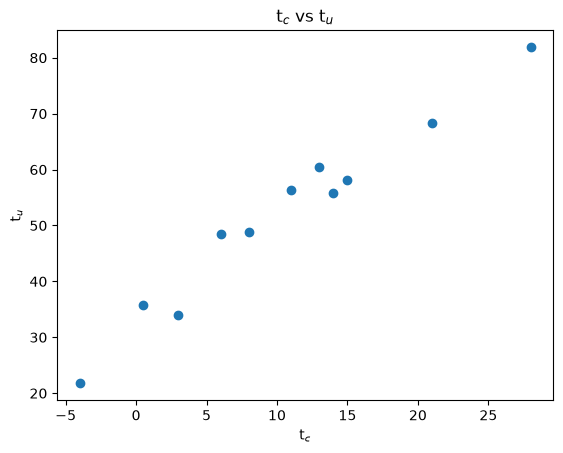

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

t_c = torch.tensor([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])
plt.figure()
plt.plot(t_c, t_u, 'o')  # scatter-style plot
plt.xlabel("t$_c$")
plt.ylabel("t$_u$")
plt.title("t$_c$ vs t$_u$")
plt.show()

# Linear regression: model definition

We assume the simplest possible model for converting between the two sets of measurements: a linear model by the unknown parameters $w,b$:
$$
t_c = w t_u +b
$$
We will refer to $w$ as weight and to $b$ as bias, a recurrent terminology. We want to compute parameters defining the *best* fitting of the data.

Hence we start defining a function `model` that, given $t_u$ and an estimate of $w,b$, outputs the predicted transformed temperatures


In [2]:
def model(t_u, w, b):
    return w * t_u + b

Let us for instance choose arbitrary values for the wieght and the bias and predict $t_p$:

In [3]:
w = torch.ones(()) # w = 1, a zero-order tensor
b = torch.zeros(())  # b = 0, a zero-order tensor

t_p = model(t_u, w, b)
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

# Loss function
The *distance* between the Celsius temperature $t_c$ and the predicted $t_p$, called *loss* is now computed as:
$$
{\cal L} = MSE = \frac{1}{N} \sum_{i=1}^{N} (t_c[i] - t_p[i])^2
$$
implemented in function `loss_fn`

In [4]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()


Note that `(t_p - t_c)**2` squares each element of the vector individually. This is called element-wise squaring.
If for instance we take the current $t_p$ an $t_c$ we have


In [5]:
loss = loss_fn(t_p, t_c)
print(loss)

tensor(1763.8848)


# Loss gradient

We first compute the gradient of the loss function with respect to $w$ and $b$:
$$
\frac{\partial \cal L}{\partial w}=\frac{2}{N}(t_p-t_c)\cdot t_u = \frac{2}{N}\sum_i(t_p[i]-t_c[i])t_u[i] \qquad
\frac{\partial \cal L}{\partial b}=\frac{2}{N}(t_p-t_c)\cdot 1= \frac{2}{N}\sum_i(t_p[i]-t_c[i])
$$



In [6]:
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)  # comment 3
    return dsq_diffs

def dmodel_dw(t_u, w, b):
    return t_u

def dmodel_db(t_u, w, b):
    return 1.0

def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)  # comment 1
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])  # comment 2

In [7]:
grad_fn(t_u, t_c, t_p, w, b)

tensor([4517.2964,   82.6000])

**Comments**
1. If `a` and `b` are torch 1D tensors then `c=a*b` is the elementwise product, that is a 1D torch tensors with same dimensions having `c[i]=a[i]*b[i]` as elements. On the contrary `torch.dot(a,b)`  is the dot product.
2. `torch.stack` creates a 1D tensor of size 2 starting form 0D tensors (scalars) a and b.
3. In torch when we multily a 0D tensor (scalar) with a 1D tensor, the result is a 1D tensor where the scalar multiplication has been applied to all the elements. This is a form of *broadcasting*, which is much more general


# Loss minimisation (training)
We’ll optimize the loss function with respect to the parameters using the **gradient descent algorithm**. In this section, we’ll build our intuition for how gradient descent
works from first principles ``params = params - learning_rate * grad ``

It is also wise to change the parameters slowly in general, because the rate of change could be dramatically
different at a distance from the neighborhood of the current w value. Therefore, we typically should scale the rate of change by a small factor. This scaling factor has many names; the one we use in machine learning is learning_rate, e.g. ``learning_rate = 1e-2``

We call a training iteration during which we update the parameters for all of our training samples an ``epoch``


In [8]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c, printparam=False) :
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b)  # evaluate the model
        loss = loss_fn(t_p, t_c) # and the loss 
        grad = grad_fn(t_u, t_c, t_p, w, b)  # and the gradient

        params -= learning_rate * grad  # update the parameters

        if printparam :
            print('Epoch %d, Loss %f' % (epoch, float(loss))) 
            
    return params, loss

Let's see what we get with some choices of the input parameters

In [9]:
training_loop(n_epochs = 100, 
              learning_rate = 1e-2, 
              params = torch.tensor([1.0, 0.0]), 
              t_u = t_u, 
              t_c = t_c)

(tensor([nan, nan]), tensor(nan))

It becomes unstable... Let's decrease the learning rate till we have a stable behaviour.  ``learning_rate = 1e-4`` is an admissible choice, even though convergence is extremely slow

<div style="text-align: center;">
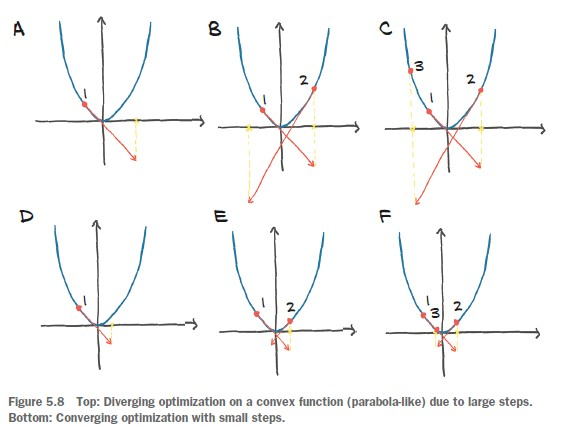
</div>



In [10]:
training_loop(n_epochs = 100, 
              learning_rate = 1e-4, 
              params = torch.tensor([1.0, 0.0]), 
              t_u = t_u, 
              t_c = t_c,
              printparam=True)

Epoch 1, Loss 1763.884766
Epoch 2, Loss 323.090515
Epoch 3, Loss 78.929634
Epoch 4, Loss 37.552845
Epoch 5, Loss 30.540283
Epoch 6, Loss 29.351154
Epoch 7, Loss 29.148884
Epoch 8, Loss 29.113848
Epoch 9, Loss 29.107145
Epoch 10, Loss 29.105247
Epoch 11, Loss 29.104168
Epoch 12, Loss 29.103222
Epoch 13, Loss 29.102295
Epoch 14, Loss 29.101379
Epoch 15, Loss 29.100466
Epoch 16, Loss 29.099548
Epoch 17, Loss 29.098631
Epoch 18, Loss 29.097717
Epoch 19, Loss 29.096796
Epoch 20, Loss 29.095881
Epoch 21, Loss 29.094959
Epoch 22, Loss 29.094049
Epoch 23, Loss 29.093134
Epoch 24, Loss 29.092216
Epoch 25, Loss 29.091301
Epoch 26, Loss 29.090385
Epoch 27, Loss 29.089464
Epoch 28, Loss 29.088551
Epoch 29, Loss 29.087635
Epoch 30, Loss 29.086714
Epoch 31, Loss 29.085804
Epoch 32, Loss 29.084888
Epoch 33, Loss 29.083967
Epoch 34, Loss 29.083057
Epoch 35, Loss 29.082142
Epoch 36, Loss 29.081221
Epoch 37, Loss 29.080309
Epoch 38, Loss 29.079390
Epoch 39, Loss 29.078474
Epoch 40, Loss 29.077562
Epoch 

(tensor([ 0.2327, -0.0438]), tensor(29.0227))

# Normalising the input
We can see that the first-epoch gradient for the weight is about 50 times larger than
the gradient for the bias. This means the weight and bias live in differently scaled
spaces. If this is the case, a learning rate that’s large enough to meaningfully update
one will be so large as to be unstable for the other; and a rate that’s appropriate for
the other won’t be large enough to meaningfully change the first
There’s a simpler way to keep things in check: changing the inputs so that the gradients
aren’t quite so different. We can make sure the range of the input doesn’t get
too far from the range of –1.0 to 1.0, roughly speaking. In our case, we can achieve
something close enough to that by simply multiplying t_u by 0.1

In [11]:
t_un = 0.1 * t_u

In [12]:
training_loop(n_epochs = 100, 
              learning_rate = 1e-2, 
              params = torch.tensor([1.0, 0.0]), 
              t_u = t_un, # <1>
              t_c = t_c)

(tensor([ 2.7553, -2.5162]), tensor(22.1487))

In [13]:
params,loss = training_loop(
              n_epochs = 5000, 
              learning_rate = 1e-2, 
              params = torch.tensor([1.0, 0.0]), 
              t_u = t_un, # <1>
              t_c = t_c)

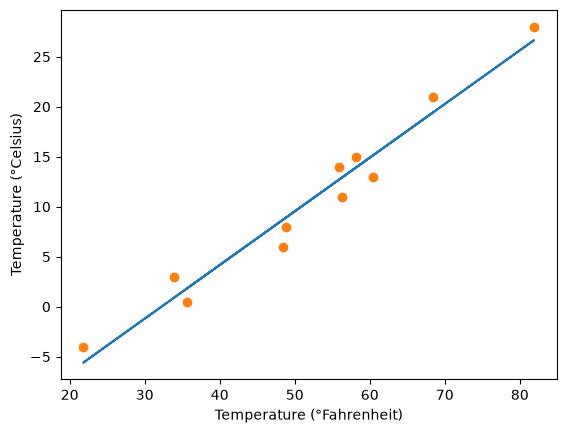

In [14]:
t_p = model(t_un, *params)  # <1>

#fig = plt.figure(dpi=600)
fig = plt.figure()
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_p.detach().numpy()) 
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
#plt.savefig("temp_unknown_plot.png", format="png")  
plt.show()

**Comments**\
We are using a Python trick called argument unpacking here `*params` means to pass the
elements of params as individual arguments. In Python, this is usually done with lists
or tuples, but we can also use argument unpacking with PyTorch tensors, which are
split along the leading dimension. So here, `model(t_un, *params)` is equivalent to
`model(t_un, params[0], params[1])`. Comment on `detach`

# PyTorch autograd
PyTorch tensors can remember where they come from, in terms of the operations and parent tensors that originated them, and they can automatically provide the chain of
derivatives of such operations with respect to their inputs. Given a forward expression, no matter how nested,
PyTorch will automatically build a *computation graph* and provide the gradient of that expression with respect to its input parameters.
\

BENJO PAG 199 ADD EXPLANATIONS


In [15]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
loss = loss_fn(model(t_u, *params), t_c)
loss.backward()
params.grad

tensor([4517.2969,   82.6000])

**WARNING** Calling ``backward`` will add to the current gradient. We need to set to zero the gradient explicitly before each call to ``backward``

In [16]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:  # see comments
            params.grad.zero_()
        
        t_p = model(t_u, *params) 
        loss = loss_fn(t_p, t_c)
        loss.backward()
        
        with torch.no_grad():  # <2>
            params -= learning_rate * params.grad

        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            
    return params

**Comments**\
In PyTorch, every tensor with `requires_grad=True` can have a `.grad` attribute.
Before `backward()`  then `params.grad is None`, while after `loss.backward()`  `params.grad` contains the computed gradients 
Without `torch.no_grad()`, PyTorch would:
* Track this subtraction
* Add it to the computation graph
* Try to compute gradients through your update step
* Grow the graph every epoch
* Eventually break or explode memory

In [17]:
training_loop(
             n_epochs = 5000, 
             learning_rate = 1e-2, 
             params = torch.tensor([1.0, 0.0], requires_grad=True), # <1> 
             t_u = t_un, # <2> 
             t_c = t_c)

C:\Users\user\AppData\Local\Temp\ipykernel_20452\2269778189.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print('Epoch %d, Loss %f' % (epoch, float(loss)))


Epoch 500, Loss 7.860115
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

# Default PyTorch Optimizers

We have so far used used vanilla gradient descent for optimization. However, the torch module has an optim submodule where we can find classes implementing different optimization algorithms

In [20]:
import torch.optim as optim
dir(optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Muon',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 '_muon',
 '_stateless',
 'lr_scheduler',
 'swa_utils',
 'swap_in_optimizer_params_and_state']

For instance **SGD** stands for stochastic gradient descent. Actually, the optimizer itself is exactly a
vanilla gradient descent (as long as the momentum argument is set to 0.0, which is the
default). The term stochastic comes from the fact that the gradient is typically obtained
by averaging over a random subset of all input samples, called a minibatch

In [21]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

Now we can define the new `training_loop` module 

In [22]:
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params) 
        loss = loss_fn(t_p, t_c)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            
    return params

and launch it:

In [23]:
training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    params = params, # <1> 
    t_u = t_un,
    t_c = t_c)

Epoch 500, Loss 57.373318
Epoch 1000, Loss 44.784958
Epoch 1500, Loss 37.901421
Epoch 2000, Loss 34.128048
Epoch 2500, Loss 32.050251
Epoch 3000, Loss 30.896940
Epoch 3500, Loss 30.247673
Epoch 4000, Loss 29.873213
Epoch 4500, Loss 29.648615
Epoch 5000, Loss 29.505749


tensor([2.2361, 0.0655], requires_grad=True)

**Adam** is a more sophisticated optimizer in which the learning rate is set adaptively. In addition, it is a lot less
sensitive to the scaling of the parameters, so that we can even avoid rescaling our $t_u$ in this simple example:

In [24]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate) 

training_loop(
    n_epochs = 2000, 
    optimizer = optimizer,
    params = params,
    t_u = t_u, 
    t_c = t_c)

Epoch 500, Loss 7.612898
Epoch 1000, Loss 3.086700
Epoch 1500, Loss 2.928579
Epoch 2000, Loss 2.927644


tensor([  0.5367, -17.3021], requires_grad=True)

# Training set and validation set
If the model we adopt has a large *capacity* which means it can potentially approximate functions of any shape, as in the case of neural networks there is the risk of overfitting. In other words, a highly adaptable model will tend to use its many parameters to make
sure the loss is minimal at the data points, but we’ll have no guarantee that the model behaves well away from or in between the data points. After all, that’s what we’re asking the optimizer to do: minimize the loss at the data points. Sure enough, if we had independent
data points that we didn’t use to evaluate our loss or descend along its negative
gradient, we would soon find out that evaluating the loss at those independent
data points would yield higher-than-expected loss. This phenomenon, called *overfitting*.

<div style="text-align: center;">
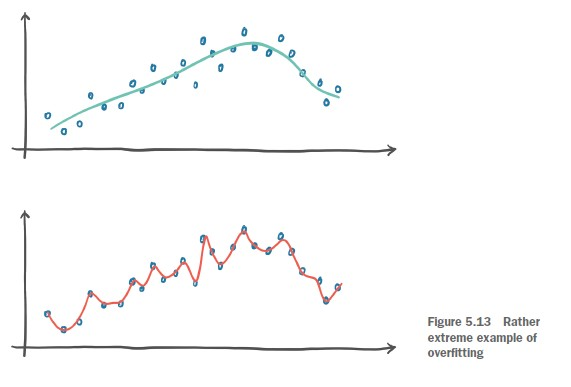
</div>

Assuming we have enough data points, we should make sure the model that is
capable of fitting the training data is as regular as possible in between them. There are
several ways to achieve this. One is adding penalization terms to the loss function, to
make it cheaper for the model to behave more smoothly and change more slowly (up
to a point). Another is to add noise to the input samples, to artificially create new data
points in between training data samples and force the model to try to fit those, too.
There are several other ways, all of them somewhat related to these. But the best favor
we can do to ourselves, at least as a first move, is to make our model simpler. From an
intuitive standpoint, a simpler model may not fit the training data as perfectly as a
more complicated model would, but it will likely behave more regularly in between
data points. 
The first action we can take to combat overfitting is recognizing that it might happen.
In order to do so we must take a few data points out of our dataset (the validation set) and only fit our model on the remaining data
points (the training set). Then, while we’re fitting the model, we can evaluate the loss once on the training set and once on the validation set. When
we’re trying to decide if we’ve done a good job of fitting our model to the data, we must look at both.


In [25]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)  # number of elements of the validation set

shuffled_indices = torch.randperm(n_samples)  # shuffling indices by applying a random permutation
print(shuffled_indices)

val_indices = shuffled_indices[-n_val:]   # last n_val elements
train_indices = shuffled_indices[:-n_val]  # all the rest

print(train_indices, val_indices)

train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u  # scaling
val_t_un = 0.1 * val_t_u

tensor([ 3,  1,  9,  7, 10,  8,  6,  5,  4,  2,  0])
tensor([ 3,  1,  9,  7, 10,  8,  6,  5,  4]) tensor([2, 0])


``shuffled_indices[-n_val:]`` is Python *slicing* and amounts to asking: give me the last n_val elements!
It says: start n_val elements from the end and go until the end of the list

In [26]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u,
                  train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params) # <1>
        train_loss = loss_fn(train_t_p, train_t_c)
                             
        val_t_p = model(val_t_u, *params) 
        val_loss = loss_fn(val_t_p, val_t_c)
        
        optimizer.zero_grad()
        train_loss.backward() 
        optimizer.step()

        if epoch <= 3 or epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                  f" Validation loss {val_loss.item():.4f}")
            
    return params

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_un, # <1> 
    val_t_u = val_t_un, # <1> 
    train_t_c = train_t_c,
    val_t_c = val_t_c)

Epoch 1, Training loss 719.6323, Validation loss 551.8691
Epoch 2, Training loss 702.8497, Validation loss 537.9788
Epoch 3, Training loss 674.2529, Validation loss 514.4735
Epoch 500, Training loss 4.4079, Validation loss 4.9491
Epoch 1000, Training loss 3.2728, Validation loss 2.4170
Epoch 1500, Training loss 3.2106, Validation loss 1.9340
Epoch 2000, Training loss 3.2093, Validation loss 1.8644
Epoch 2500, Training loss 3.2093, Validation loss 1.8587
Epoch 3000, Training loss 3.2093, Validation loss 1.8585
Epoch 3500, Training loss 3.2093, Validation loss 1.8585
Epoch 4000, Training loss 3.2093, Validation loss 1.8585
Epoch 4500, Training loss 3.2093, Validation loss 1.8585
Epoch 5000, Training loss 3.2093, Validation loss 1.8585


tensor([  5.2528, -16.6644], requires_grad=True)

The validation set is really small, so
the validation loss will only be meaningful up to a point. In any case, we note that the
validation loss is higher than our training loss, although not by an order of magnitude.
We expect a model to perform better on the training set, since the model
parameters are being shaped by the training set. Our main goal is to also see both the
training loss and the validation loss decreasing. While ideally both losses would be
roughly the same value, as long as the validation loss stays reasonably close to the
training loss, we know that our model is continuing to learn generalized things about
our data. In figure 5.14, case C is ideal, while D is acceptable. In case A, the model
isn’t learning at all; and in case B, we see overfitting

<div style="text-align: center;">
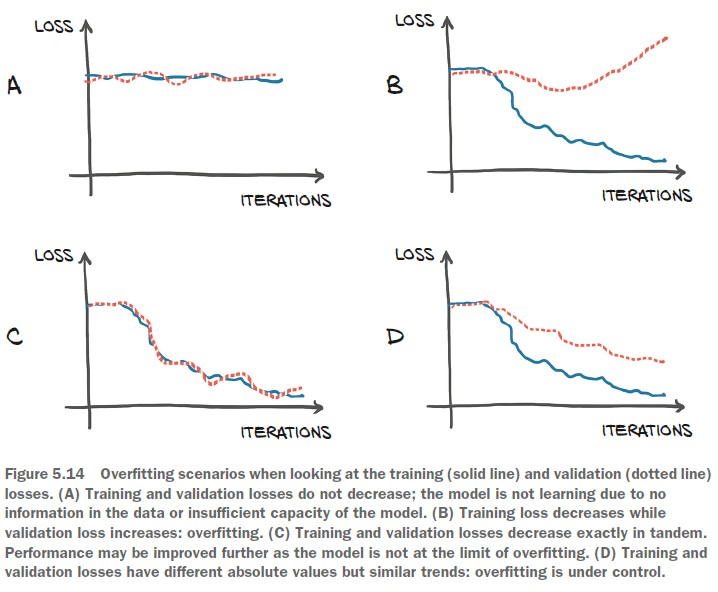
</div>


The only tensors these two graphs have in common are the parameters. When we call
backward on train_loss, we run backward on the first graph. In other words, we
accumulate the derivatives of train_loss with respect to the parameters based on the
computation generated from train_t_u.
If we (incorrectly) called backward on val_loss as well, we would accumulate the
derivatives of val_loss with respect to the parameters on the same leaf nodes

However using `with torch.no_grad()` one can explicitely avoid the creation of the graph

An alternative is to use `.detach`

In [27]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u,
                  train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)

        with torch.no_grad(): 
            val_t_p = model(val_t_u, *params)
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False 
            
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

# Exercise
Redefine the model to be $w_2 t_u^2 + w_1 t_u + b$.
1. What parts of the training loop, and so on, need to change to accommodate
this redefinition?
2. What parts are agnostic to swapping out the model?
3. Is the resulting loss higher or lower after training?
4. Is the actual result better or worse?